<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK06/abalone_DL_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/WEEK06/abalone.csv'

In [36]:
# abalone.csv 파일을 바탕으로 딥러닝(Deep Learning) classification 실습

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CSV 파일을 DataFrame 형태로 읽기
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [37]:
# 데이터 전체 확인
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [38]:
# 컬렴명 확인
df.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
       'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

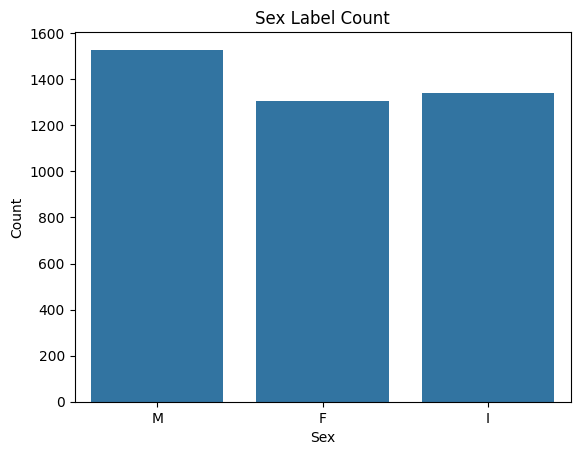

In [39]:
# 레이블 개수 확인 (그래프)
sns.countplot(data=df, x='Sex')
plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Sex Label Count")
plt.show()

In [40]:
# 레이블 개수 확인 (숫자)
print(df['Sex'].value_counts())

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


In [41]:
# 결측치 확인
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [42]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [43]:
# 정답 데이터(y) 설정
# Sex 컬럼이 분류해야 할 목표값(레이블)이다.
y = df['Sex']
print(y.value_counts())

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


In [44]:
# 입력 데이터(X) 생성
# Sex를 예측해야 하므로 Sex 컬럼은 제외한다.
X = df.drop('Sex', axis=1)
X.head()

,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [45]:
# 원-핫 인코딩
# 출력층 형태와 정답 데이터 형태를 맞추기 위해 원-핫 인코딩을 한다.
# 다중 분류 문제이므로 각 클래스를 0과 1로 이루어진 벡터 형태로 변환한다.
# 예: 클래스 1 -> [1,0,0], 클래스 2 -> [0,1,0], 클래스 3 -> [0,0,1]
# 딥러닝 모델의 출력층이 보통 각 클래스별 확률을 여러 개 출력하기 때문이다.
# 예시) [0.1, 0.8, 0.1]

Y = pd.get_dummies(y).values

In [46]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
# 표준화는 데이터의 각 feature를 비슷한 크기 범위로 맞추는 작업이다.
# 각 feature의 평균을 0, 표준편차를 1에 가깝게 맞춰 학습 성능을 높인다.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [47]:
from sklearn.model_selection import train_test_split

# 학습용 데이터와 테스트용 데이터 분리
# test_size=0.2 -> 전체 데이터의 20%를 테스트용으로 사용
# y 대신 원-핫 인코딩된 Y를 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0    # y를 Y로 변경
)

In [48]:
# 딥러닝 모델 생성
# 입력층 -> 은닉층1 -> Dropout -> 은닉층2 -> 출력층 구조
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),  # X.shape[1] = 입력 feature의 개수
    layers.Dropout(0.3),     # 과적합 방지를 위해 일부 뉴런을 무작위로 비활성화
    layers.Dense(32, activation='relu'),
    layers.Dense(Y.shape[1], activation='softmax')    # Y.shape[1] = 클래스 개수, 클래스 수만큼 출력 노드 설정
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# 모델 컴파일
# optimizer='adam' : 가중치 최적화 방법
# loss='categorical_crossentropy' : 원-핫 인코딩된 다중분류 손실 함수
# metrics=['accuracy'] : 정확도를 평가지표로 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # one-hot이면 categorical_crossentropy
    metrics=['accuracy']
)

In [50]:
# 모델 학습
# validation_split=0.2 : 학습 데이터 중 20%를 검증용으로 사용
# epochs=50 : 전체 데이터를 50번 반복 학습
# batch_size=16 : 한 번에 16개씩 나누어 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5288 - loss: 0.9058 - val_accuracy: 0.5277 - val_loss: 0.8521
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5258 - loss: 0.8735 - val_accuracy: 0.5291 - val_loss: 0.8437
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5367 - loss: 0.8635 - val_accuracy: 0.5321 - val_loss: 0.8361
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5438 - loss: 0.8601 - val_accuracy: 0.5471 - val_loss: 0.8322
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5374 - loss: 0.8590 - val_accuracy: 0.5546 - val_loss: 0.8288
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5472 - loss: 0.8524 - val_accuracy: 0.5516 - val_loss: 0.8259
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5479 - loss: 0.8494 - val_accuracy: 0.5650 - val_loss: 0.8254
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5498 - loss: 0.8477 - val_accuracy: 0.

In [51]:
# 테스트 데이터 예측
y_pred = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [52]:
# 원-핫 인코딩 -> 클래스 번호 변환
# 예: [0,1,0] -> 1
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

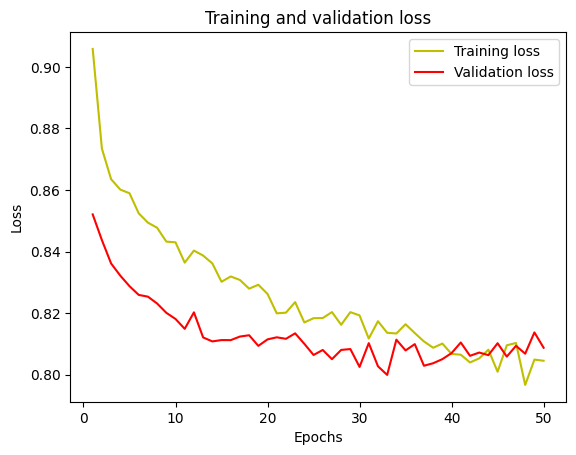

In [53]:
# Loss 그래프에 사용할 값 추출
loss = history.history['loss']
val_loss = history.history['val_loss']

# Loss 그래프
# 학습 손실과 검증 손실의 변화를 통해 모델 학습 상태를 확인
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

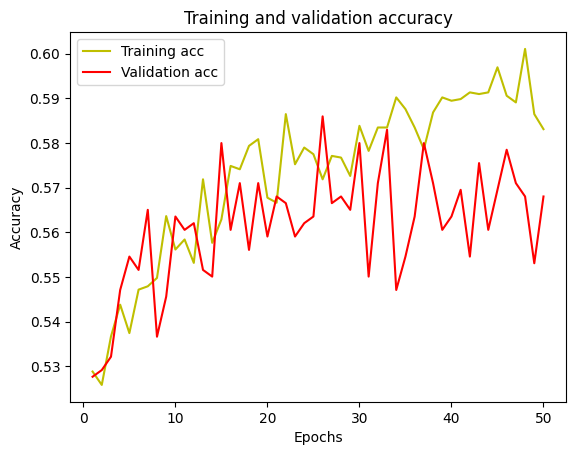

In [54]:
# Accuracy 그래프에 사용할 값 추출
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Accuracy 그래프
# 학습 정확도와 검증 정확도의 변화를 통해 모델 성능을 확인
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [55]:
# 분류 성능 평가
# classification_report : precision, recall, f1-score 출력
# confusion_matrix : 실제값과 예측값 비교표 출력
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_class, y_pred_class))
print(confusion_matrix(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.46      0.46      0.46       249
           1       0.74      0.78      0.76       291
           2       0.47      0.44      0.45       296

    accuracy                           0.57       836
   macro avg       0.56      0.56      0.56       836
weighted avg       0.56      0.57      0.56       836

[[115  26 108]
 [ 25 228  38]
 [111  55 130]]
